In [11]:
import torch
from scipy.special import softmax

weights_only = False
model_path = '../result/lada-fitting-joint/lada_joint_k3_lsat_qa.pt'

# 1) Load parameters
model_data = torch.load(model_path, map_location=torch.device('cpu'), weights_only=weights_only)
model_data_keys = list(model_data.keys())
print(f"Loaded model data keys: {model_data_keys}\n")
theta = model_data['theta']          # shape: (n_people, k)
d = model_data['d']                  # shape: (n_items,  k)
p = model_data['phi']

print("--- Initial Loaded Data ---")
print(f"Original theta shape: {theta.shape}")
print(f"Original 'd' matrix shape: {d.shape}\n")
d_numpy = d.detach().cpu().numpy()
theta_numpy = theta.detach().cpu().numpy()
p_numpy = p.detach().cpu().numpy()
# Apply softmax along axis 1 (the K dimension)
w_numpy = softmax(p_numpy, axis=1)

Loaded model data keys: ['theta', 'd', 'phi', 'metrics']

--- Initial Loaded Data ---
Original theta shape: torch.Size([183, 3])
Original 'd' matrix shape: torch.Size([454])



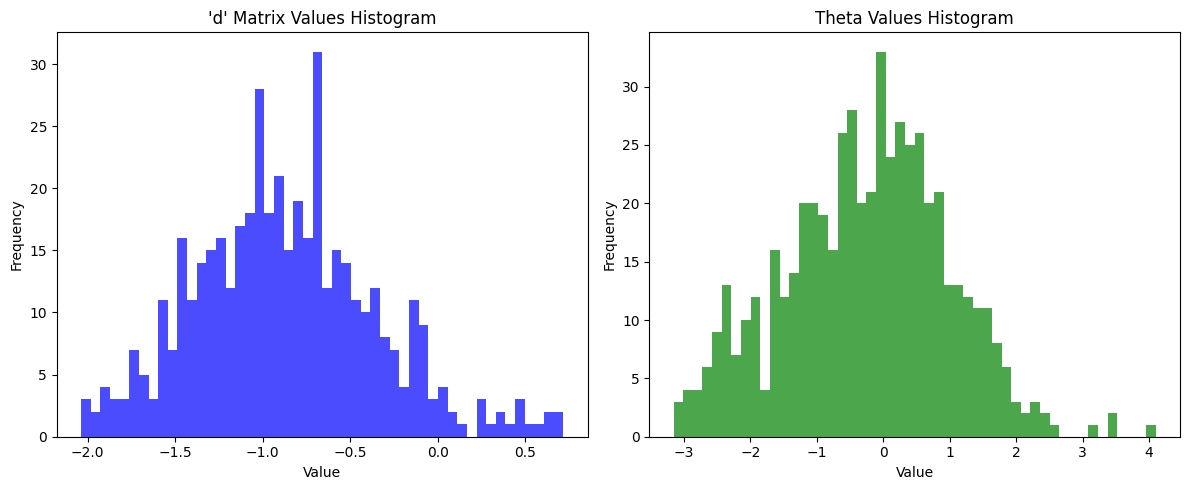

In [15]:
# plot d_numpy, theta_numpy values in a histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(d_numpy.flatten(), bins=50, color='blue', alpha=0.7)
plt.title("'d' Matrix Values Histogram")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.subplot(1, 2, 2)
plt.hist(theta_numpy.flatten(), bins=50, color='green', alpha=0.7)
plt.title("Theta Values Histogram")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import torch.nn.functional as F
import pickle

# --- 2. Load and Filter Raw Data for "lsat_qa" ---
TARGET_SCENARIO = "lsat_qa" 

try:
    print(f"Loading raw data to verify against scenario: {TARGET_SCENARIO}...")
    with open("../data-reeval-multi/resmat.pkl", "rb") as f:
        results = pickle.load(f)
        
    # FILTERING STEP:
    # We must select only the columns belonging to 'lsat_qa' to align with the model's 'd' parameter
    scenario_mask = (results.columns.get_level_values("scenario") == TARGET_SCENARIO)
    scenario_df = results.loc[:, scenario_mask]
    
    # Check alignment
    if scenario_df.shape[1] != len(d_numpy):
        print(f"WARNING: Dimension Mismatch! Data has {scenario_df.shape[1]} items, Model has {len(d_numpy)} items.")
    else:
        print(f"Dimensions aligned: {len(d_numpy)} items.")

    # Calculate Empirical Accuracy (Mean of raw responses, ignoring NaNs)
    raw_values = scenario_df.values
    raw_accuracy = np.nanmean(raw_values, axis=0)

    # ---------------------------------------------------------
    # Plot B: Learned Difficulty 'd' vs Empirical Accuracy
    # ---------------------------------------------------------
    plt.figure(figsize=(8, 6))
    plt.scatter(d_numpy, raw_accuracy, alpha=0.6, c='blue', edgecolors='k')
    
    # Add trend line
    m, b = np.polyfit(d_numpy, raw_accuracy, 1)
    plt.plot(d_numpy, m*d_numpy + b, color='red', linestyle='--', label=f'Fit: y={m:.2f}x+{b:.2f}')
    
    plt.xlabel(f"Learned Parameter $d$ (Model)")
    plt.ylabel(f"Empirical Probability Correct (Raw Data)")
    plt.title(f"Calibration Check: {TARGET_SCENARIO}\n(Correlation: {np.corrcoef(d_numpy, raw_accuracy)[0,1]:.4f})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

except FileNotFoundError:
    print("Error: '../data-reeval-multi/resmat.pkl' not found. Cannot generate Plot B.")
except KeyError:
    print(f"Error: Scenario '{TARGET_SCENARIO}' not found in dataset columns.")

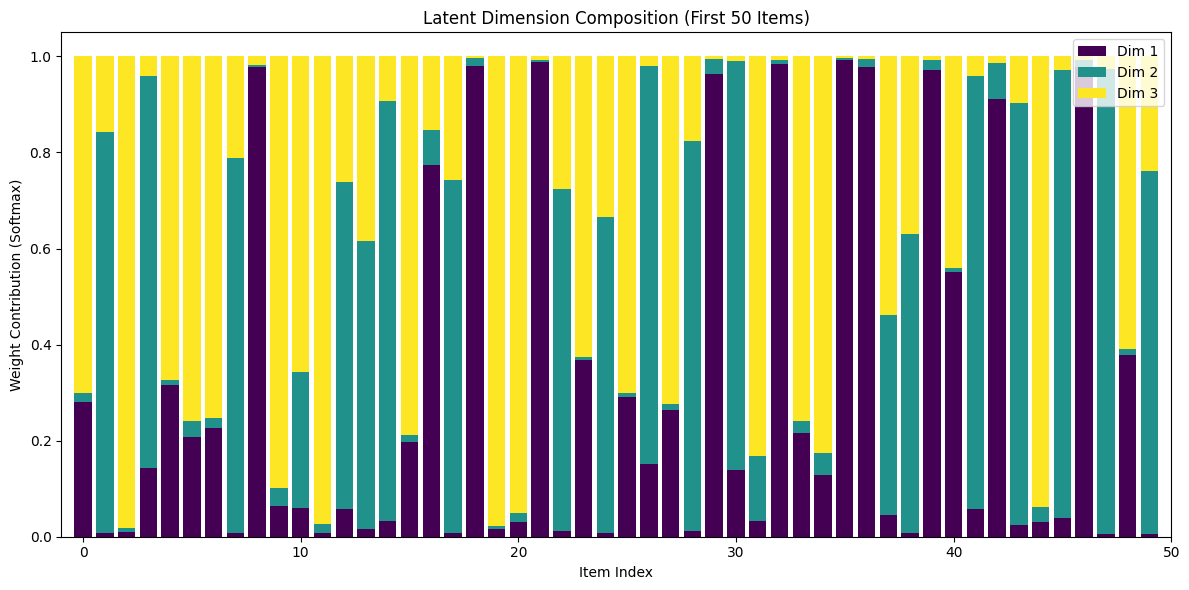

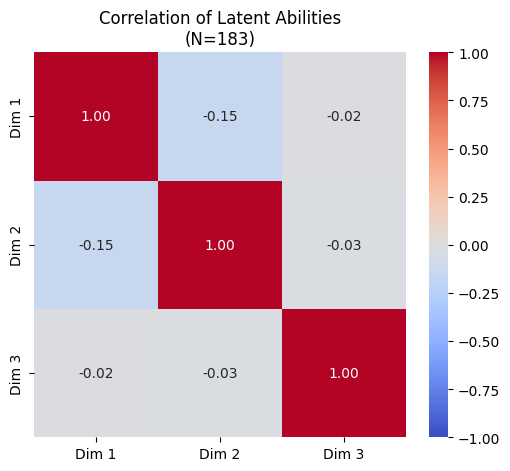

In [19]:
# ---------------------------------------------------------
# Plot A: Stacked Bar Chart of Weights (W)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
items_to_plot = min(50, w_numpy.shape[0])
# items_to_plot = w_numpy.shape[0]  
indices = np.arange(items_to_plot)
bottoms = np.zeros(items_to_plot)

colors = plt.cm.viridis(np.linspace(0, 1, w_numpy.shape[1]))

for k in range(w_numpy.shape[1]):
    plt.bar(indices, w_numpy[:items_to_plot, k], bottom=bottoms, 
            label=f'Dim {k+1}', color=colors[k], width=0.8)
    bottoms += w_numpy[:items_to_plot, k]

plt.xlim(-1, items_to_plot)
plt.xlabel("Item Index")
plt.ylabel("Weight Contribution (Softmax)")
plt.title(f"Latent Dimension Composition (First {items_to_plot} Items)")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Plot C: Theta Correlations
# ---------------------------------------------------------
plt.figure(figsize=(6, 5))
theta_df = pd.DataFrame(theta_numpy, columns=[f"Dim {k+1}" for k in range(theta_numpy.shape[1])])
sns.heatmap(theta_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title(f"Correlation of Latent Abilities\n(N={len(theta_df)})")
plt.show()